# EDA: Explainable Grammatical Error Correction Dataset

**Репозиторий:** [lorafei/Explainable_GEC](https://github.com/lorafei/Explainable_GEC)  
**Задача:** Grammatical Error Correction (GEC) с объяснимой коррекцией — каждый пример содержит ошибочное предложение, исправленное предложение, тип ошибки, индексы коррекции и evidence-индексы.

---

## 1. Установка и импорт библиотек

In [1]:
!pip install -q pandas ujson matplotlib seaborn

In [2]:
import pandas as pd
import ujson as json
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

## 2. Загрузка датасета

In [3]:
!git clone https://github.com/lorafei/Explainable_GEC.git 2>/dev/null || echo 'already cloned'

already cloned


In [4]:
DATA_DIR = Path("Explainable_GEC/data/json")

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_train = load_jsonl(DATA_DIR / "train.json")
df_dev   = load_jsonl(DATA_DIR / "dev.json")
df_test  = load_jsonl(DATA_DIR / "test.json")

# Пометим сплиты и объединим для общего анализа
df_train["split"] = "train"
df_dev["split"]   = "dev"
df_test["split"]  = "test"

df = pd.concat([df_train, df_dev, df_test], ignore_index=True)

print(f"train: {len(df_train):>6,}")
print(f"dev:   {len(df_dev):>6,}")
print(f"test:  {len(df_test):>6,}")
print(f"total: {len(df):>6,}")

train: 15,187
dev:    2,413
test:   2,416
total: 20,016


## 3. Первичный осмотр

In [5]:
df.head(3)

,target,source,evidence_index,correction_index,error_type,predicted_parsing_order,origin,split
0,"[It, has, a, high, -, density, population, bec...","[It, has, a, high, -, density, population, bec...","[7, 9, 10, 11, 21, 23, 24, 25]","[8, 22]",Preposition,"{'1': 3, '5': 2, '7': 2, '8': 1, '9': 3, '10':...",A,train
1,"[Although, [NONE], it, is, an, industrial, cit...","[Although, of, it, is, an, industrial, city, ,...","[0, 17]","[1, 18]",Preposition,"{'1': 1, '18': 1}",A,train
2,"[Although, it, is, an, industrial, city, ,, th...","[Despite, it, is, an, industrial, city, ,, the...",[],"[0, 16]",Collocation,"{'0': 1, '5': 2, '8': 3, '16': 1, '21': 2, '24...",A,train


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20016 entries, 0 to 20015
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   target                   20016 non-null  object
 1   source                   20016 non-null  object
 2   evidence_index           20016 non-null  object
 3   correction_index         20016 non-null  object
 4   error_type               20016 non-null  str   
 5   predicted_parsing_order  20016 non-null  object
 6   origin                   20016 non-null  str   
 7   split                    20016 non-null  str   
dtypes: object(5), str(3)
memory usage: 1.2+ MB


In [7]:
# Пример записи
row = df.iloc[0]
print("Source:", " ".join(row["source"]))
print("Target:", " ".join(row["target"]))
print("Error type:", row["error_type"])
print("Correction indices:", row["correction_index"])
print("Evidence indices:", row["evidence_index"])
print("Origin:", row["origin"])

Source: It has a high - density population because [NONE] its small territory .
Target: It has a high - density population because of its small territory .
Error type: Preposition
Correction indices: [8, 22]
Evidence indices: [7, 9, 10, 11, 21, 23, 24, 25]
Origin: A


## 4. Feature engineering

In [8]:
df["source_len"] = df["source"].apply(len)
df["target_len"] = df["target"].apply(len)
df["len_diff"]   = df["target_len"] - df["source_len"]
df["n_corrections"] = df["correction_index"].apply(len)
df["n_evidence"]    = df["evidence_index"].apply(len)

# Текстовые версии предложений
df["source_text"] = df["source"].apply(lambda t: " ".join(t))
df["target_text"] = df["target"].apply(lambda t: " ".join(t))

df[["source_len", "target_len", "len_diff", "n_corrections", "n_evidence"]].describe().round(2)

,source_len,target_len,len_diff,n_corrections,n_evidence
count,20016.00,20016.00,20016.00,20016.00,20016.00
mean,28.76,28.79,0.03,2.21,3.78
std,21.91,21.93,0.43,0.87,3.82
min,1.00,2.00,-4.00,2.00,0.00
25%,16.00,16.00,0.00,2.00,0.00
50%,23.00,23.00,0.00,2.00,4.00
75%,34.00,34.00,0.00,2.00,6.00
max,236.00,236.00,4.00,34.00,60.00


## 5. Типы ошибок

In [9]:
print(f"Всего категорий ошибок: {df['error_type'].nunique()}\n")

error_counts = df["error_type"].value_counts()
error_pct    = (error_counts / len(df) * 100).round(1)

pd.DataFrame({"count": error_counts, "%": error_pct})

Всего категорий ошибок: 15



,count,%
error_type,,
Preposition,2789,13.9
Collocation,2683,13.4
Verb Tense,2451,12.2
Others,2043,10.2
Number,1990,9.9
Article,1513,7.6
POS Confusion,1279,6.4
Subject-Verb Agreement,1167,5.8
Possessive,1091,5.5


/var/folders/hc/rryv_cv577d273445trcn9fw0000gp/T/ipykernel_21992/1885223634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.values, y=error_counts.index, palette="viridis", ax=ax)


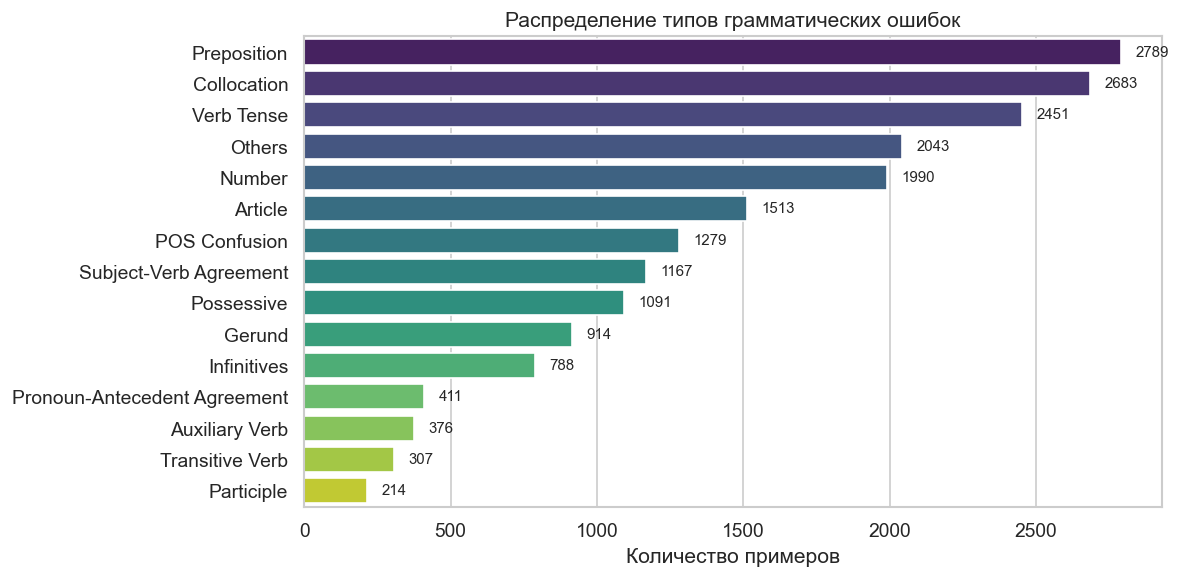

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=error_counts.values, y=error_counts.index, palette="viridis", ax=ax)
ax.set_xlabel("Количество примеров")
ax.set_ylabel("")
ax.set_title("Распределение типов грамматических ошибок")
for i, v in enumerate(error_counts.values):
    ax.text(v + 50, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Распределение по origin (уровень владения)

origin
A    8888
B    7678
C    3076
N     374
Name: count, dtype: int64


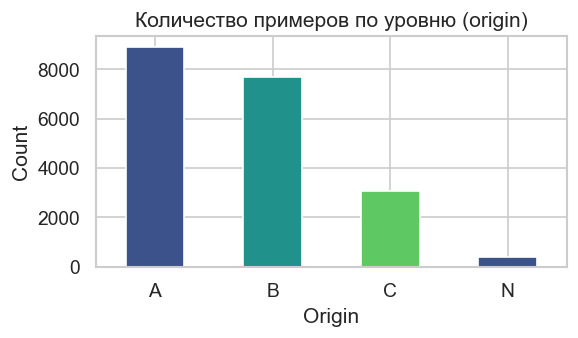

In [11]:
origin_counts = df["origin"].value_counts().sort_index()
print(origin_counts)

fig, ax = plt.subplots(figsize=(5, 3))
origin_counts.plot.bar(color=sns.color_palette("viridis", 3), ax=ax)
ax.set_title("Количество примеров по уровню (origin)")
ax.set_ylabel("Count")
ax.set_xlabel("Origin")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Типы ошибок × Origin

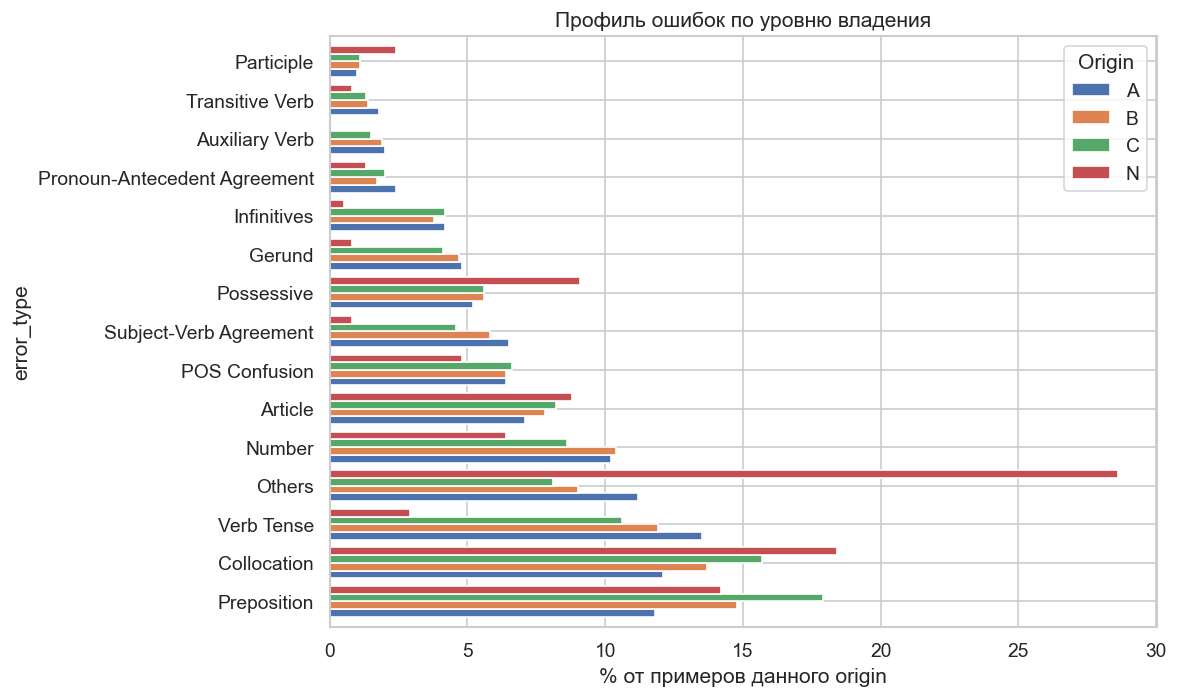

In [12]:
ct = pd.crosstab(df["error_type"], df["origin"], normalize="columns").round(3) * 100
ct = ct.loc[error_counts.index]  # сортируем по частоте

fig, ax = plt.subplots(figsize=(10, 6))
ct.plot.barh(ax=ax, width=0.8)
ax.set_xlabel("% от примеров данного origin")
ax.set_title("Профиль ошибок по уровню владения")
ax.legend(title="Origin")
plt.tight_layout()
plt.show()

## 8. Длины предложений

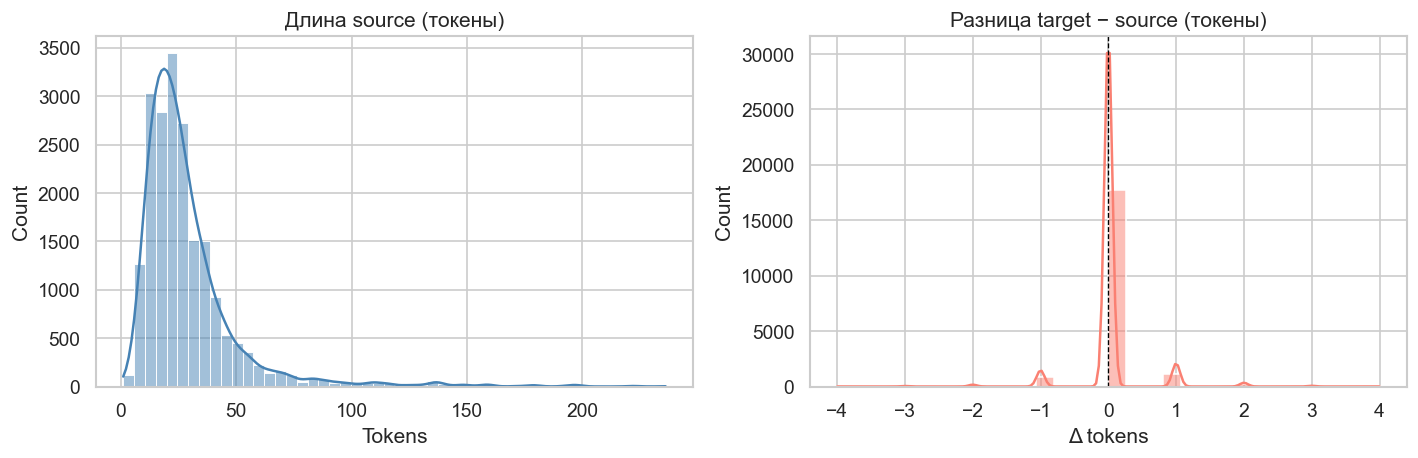

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["source_len"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Длина source (токены)")
axes[0].set_xlabel("Tokens")

sns.histplot(df["len_diff"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Разница target − source (токены)")
axes[1].set_xlabel("Δ tokens")
axes[1].axvline(0, color="black", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

In [14]:
# Средние длины по типу ошибки
len_by_error = (
    df.groupby("error_type")[["source_len", "target_len"]]
      .agg(["mean", "median"])
      .sort_values(("source_len", "mean"), ascending=False)
      .round(1)
)
len_by_error

source_len        target_len       
                                   mean median       mean median
error_type                                                      
Pronoun-Antecedent Agreement       32.0   26.0       31.9   26.0
Verb Tense                         30.1   23.0       30.1   23.0
Others                             29.7   24.0       29.9   24.0
Preposition                        29.7   24.0       29.7   24.0
Infinitives                        29.4   25.0       29.6   25.0
Subject-Verb Agreement             28.6   23.0       28.6   23.0
POS Confusion                      28.4   23.0       28.4   23.0
Gerund                             28.0   24.0       27.9   24.0
Auxiliary Verb                     28.0   23.0       28.0   23.0
Number                             27.9   23.0       28.0   23.0
Article                            27.9   23.0       27.9   23.0
Participle                         27.7   23.5       27.8   23.5
Transitive Verb                    27.7   24.0       27.7   24.0
Possessive                         27.6   22.0       27.6   22.0
Collocation                        27.6   23.0       27.6   23.0

In [15]:
# Средние длины по origin
len_by_origin = (
    df.groupby("origin")[["source_len", "target_len"]]
      .agg(["mean", "median"])
      .sort_index()
      .round(1)
)
len_by_origin

source_len        target_len       
             mean median       mean median
origin                                    
A            30.7   23.0       30.8   23.0
B            27.0   23.0       27.0   23.0
C            27.5   24.5       27.5   25.0
N            29.1   26.5       29.2   26.0

## 9. Количество коррекций и evidence-индексов

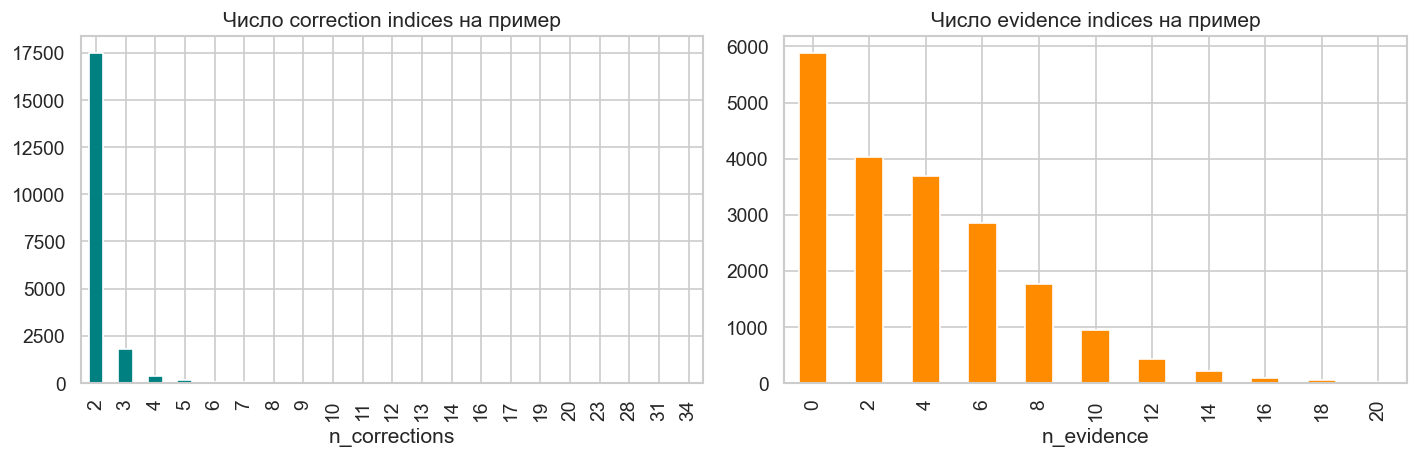

Примеры без evidence: 5885 (29.4%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["n_corrections"].value_counts().sort_index().plot.bar(ax=axes[0], color="teal")
axes[0].set_title("Число correction indices на пример")
axes[0].set_xlabel("n_corrections")

ev_vc = df["n_evidence"].value_counts().sort_index()
ev_vc[ev_vc.index <= 20].plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Число evidence indices на пример")
axes[1].set_xlabel("n_evidence")

plt.tight_layout()
plt.show()

print(f"Примеры без evidence: {(df['n_evidence'] == 0).sum()} ({(df['n_evidence'] == 0).mean()*100:.1f}%)")

## 10. Сравнение сплитов (train / dev / test)

In [17]:
split_summary = (
    df.groupby("split")
      .agg(
          n=("error_type", "size"),
          n_error_types=("error_type", "nunique"),
          avg_src_len=("source_len", "mean"),
          avg_tgt_len=("target_len", "mean"),
          avg_corrections=("n_corrections", "mean"),
      )
      .round(2)
)
split_summary

,n,n_error_types,avg_src_len,avg_tgt_len,avg_corrections
split,,,,,
dev,2413,15,29.01,29.06,2.32
test,2416,15,29.18,29.23,2.30
train,15187,15,28.65,28.68,2.18


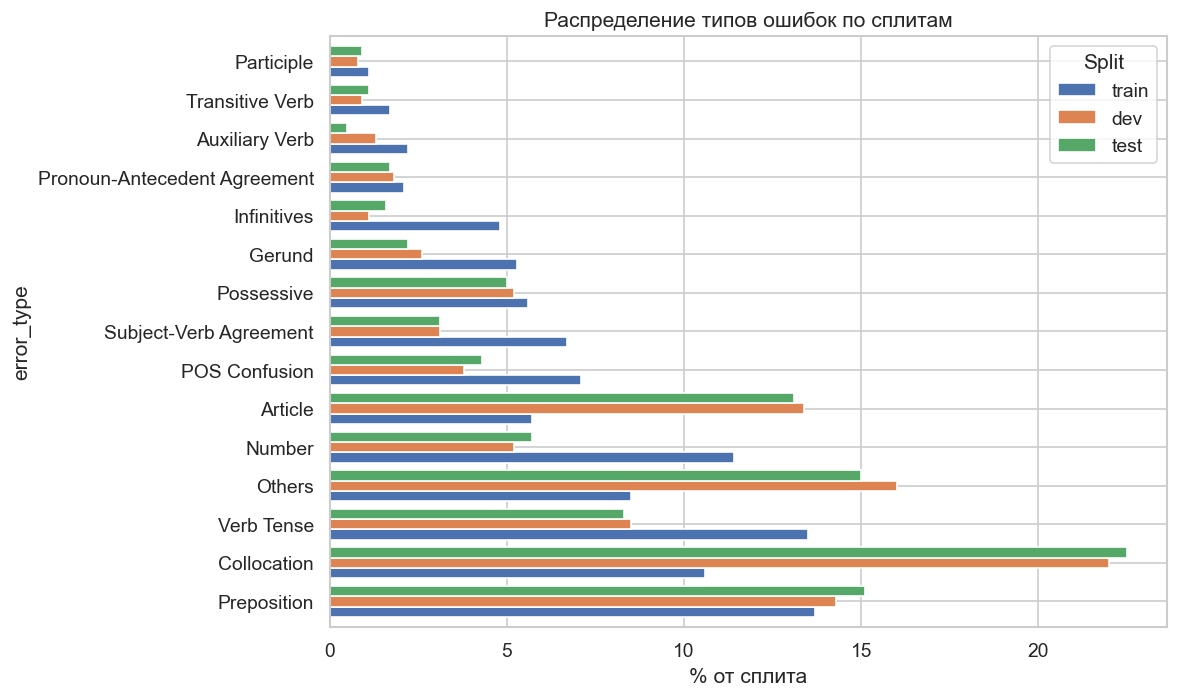

In [18]:
# Распределение ошибок одинаково по сплитам?
ct_split = pd.crosstab(df["error_type"], df["split"], normalize="columns").round(3) * 100
ct_split = ct_split.loc[error_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ct_split[["train", "dev", "test"]].plot.barh(ax=ax, width=0.8)
ax.set_xlabel("% от сплита")
ax.set_title("Распределение типов ошибок по сплитам")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

## 11. Токен `[NONE]` — вставки и удаления

In [19]:
df["none_in_source"] = df["source"].apply(lambda t: t.count("[NONE]"))
df["none_in_target"] = df["target"].apply(lambda t: t.count("[NONE]"))

print("[NONE] в source (= нужна вставка):")
print(df["none_in_source"].value_counts().sort_index().head(5))
print(f"\nДоля примеров с [NONE] в source: {(df['none_in_source'] > 0).mean()*100:.1f}%")

print("\n[NONE] в target (= нужно удаление):")
print(df["none_in_target"].value_counts().sort_index().head(5))
print(f"\nДоля примеров с [NONE] в target: {(df['none_in_target'] > 0).mean()*100:.1f}%")

[NONE] в source (= нужна вставка):
none_in_source
0    16705
1     3311
Name: count, dtype: int64

Доля примеров с [NONE] в source: 16.5%

[NONE] в target (= нужно удаление):
none_in_target
0    18460
1     1556
Name: count, dtype: int64

Доля примеров с [NONE] в target: 7.8%


## 12. Корреляции числовых признаков

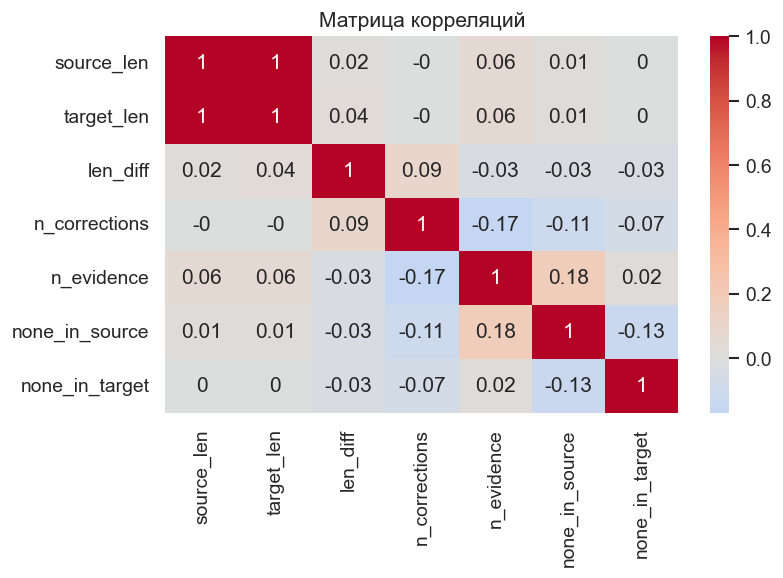

In [20]:
num_cols = ["source_len", "target_len", "len_diff", "n_corrections", "n_evidence",
            "none_in_source", "none_in_target"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[num_cols].corr().round(2), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Матрица корреляций")
plt.tight_layout()
plt.show()

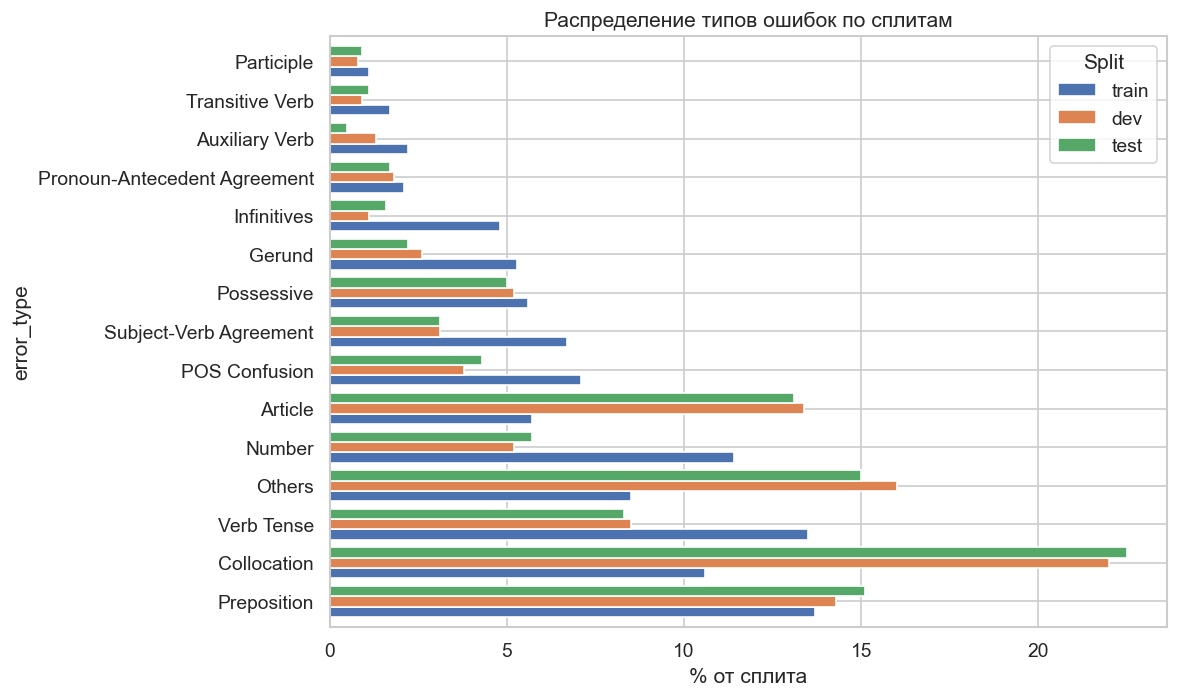

In [ ]:
# Распределение ошибок одинаково по сплитам?
ct_split = pd.crosstab(df["error_type"], df["split"], normalize="columns").round(3) * 100
ct_split = ct_split.loc[error_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ct_split[["train", "dev", "test"]].plot.barh(ax=ax, width=0.8)
ax.set_xlabel("% от сплита")
ax.set_title("Распределение типов ошибок по сплитам")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

## 13. Дополнительные данные: gector.json и t5.json

In [21]:
df_gector = load_jsonl(DATA_DIR / "gector.json")
df_t5     = load_jsonl(DATA_DIR / "t5.json")

print(f"gector.json: {len(df_gector)} samples, columns: {list(df_gector.columns)}")
print(f"t5.json:     {len(df_t5)} samples, columns: {list(df_t5.columns)}")

print("\ngector sample:")
display(df_gector.head(2))
print("\nt5 sample:")
display(df_t5.head(2))

gector.json: 501 samples, columns: ['target', 'source', 'evidence_index', 'correction_index', 'error_type', 'predicted_parsing_order']
t5.json:     500 samples, columns: ['target', 'source', 'evidence_index', 'correction_index', 'error_type', 'predicted_parsing_order']

gector sample:


,target,source,evidence_index,correction_index,error_type,predicted_parsing_order
0,"[I, have, travelled, around, most, [NONE], Eur...","[I, have, travelled, around, most, of, Europea...","[4, 6, 7, 33, 35, 36]","[5, 34]",Preposition,"{'5': 1, '34': 1}"
1,"[Hi, ., I, am, so, happy, to, write, here, .My...","[Hi, ., I, am, so, happy, to, write, here, .My...","[12, 30]","[13, 31, 32, 33]",Gerund,"{'10': 3, '12': 2, '13': 1, '14': 3, '15': 2, ..."



t5 sample:


,target,source,evidence_index,correction_index,error_type,predicted_parsing_order
0,"[On, the, other, hand, ,, in, my, leisure, tim...","[On, the, other, hand, ,, in, my, leisure, tim...",[],"[25, 60]",Others,"{'13': 3, '14': 2, '25': 1, '48': 3, '49': 2, ..."
1,"[I, have, travelled, around, most, European, c...","[I, have, travelled, around, most, European, c...","[14, 15, 16, 18, 19, 42, 43, 44, 46, 47]","[17, 45]",Preposition,"{'13': 3, '14': 2, '17': 1, '18': 3, '19': 2, ..."


## 14. Выводы

| Характеристика | Значение |
|---|---|
| Общее число примеров | 20 016 (train 15 187 / dev 2 413 / test 2 416) |
| Категорий ошибок | 15 |
| Топ-3 ошибки | Preposition (13.9%), Collocation (13.4%), Verb Tense (12.2%) |
| Средняя длина предложения | ~29 токенов (медиана 23) |
| Уровни владения (origin) | A (8 888), B (7 678), C (3 076), N (374) |
| Примеры без evidence-индексов | 29.4% |
| Сплиты сбалансированы по типам ошибок | В целом да (кроме Collocation в dev) |

Датасет подходит для задачи генерации персонализированных упражнений, так как содержит:
- типизированные ошибки (15 категорий),
- уровни владения (origin A/B/C/N),
- evidence-индексы для интерпретируемости коррекций,
- формат source/target, пригодный для обучения seq2seq-моделей.